In [1]:
#  Predictive Modeling for Risk-Based Pricing
# Building ML Models for Claims and Premium Prediction

import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import xgboost as xgb
import warnings
import shap

# Import the data processor
sys.path.append('..')
from src.data_processor import DataProcessor

# Set visualization style
plt.style.use('seaborn-v0_8')
sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print("=== PREDICTIVE MODELING FOR RISK-BASED PRICING ===")
print("Loading data and setting up modeling framework...")

# Load the dataset
data_processor = DataProcessor()
file_path = "MachineLearningRating_v3.txt"
data = data_processor.load_data(file_path, parse_dates=["TransactionMonth"], sep='|')

print(f"Data loaded successfully: {data.shape[0]:,} records, {data.shape[1]} columns")
print(f"Date range: {data['TransactionMonth'].min()} to {data['TransactionMonth'].max()}")

# Calculate key metrics for modeling
data['ClaimFrequency'] = (data['TotalClaims'] > 0).astype(int)
data['ClaimSeverity'] = np.where(data['TotalClaims'] > 0, data['TotalClaims'], np.nan)
data['Margin'] = data['TotalPremium'] - data['TotalClaims']
data['LossRatio'] = data['TotalClaims'] / data['TotalPremium'].replace(0, np.nan)

print(f"\n=== MODELING TARGETS ===")
print(f"Claim Frequency: {data['ClaimFrequency'].mean():.4f} ({data['ClaimFrequency'].mean()*100:.2f}%)")
print(f"Claim Severity (mean): {data['ClaimSeverity'].mean():.2f}")
print(f"Total Premium (mean): {data['TotalPremium'].mean():.2f}")
print(f"Total Claims (mean): {data['TotalClaims'].mean():.2f}")

# Display sample of the data
print(f"\n=== SAMPLE DATA ===")
print(data[['PolicyID', 'Province', 'VehicleType', 'TotalPremium', 'TotalClaims', 'ClaimFrequency', 'ClaimSeverity']].head(10))

2025-08-24 01:14:28,486 - src.data_processor - INFO - Loading data from ../data\MachineLearningRating_v3.txt


=== PREDICTIVE MODELING FOR RISK-BASED PRICING ===
Loading data and setting up modeling framework...


2025-08-24 01:14:36,219 - src.data_processor - INFO - Successfully loaded data with shape (1000098, 52)


Data loaded successfully: 1,000,098 records, 52 columns
Date range: 2013-10-01 00:00:00 to 2015-08-01 00:00:00

=== MODELING TARGETS ===
Claim Frequency: 0.0028 (0.28%)
Claim Severity (mean): 23273.39
Total Premium (mean): 61.91
Total Claims (mean): 64.86

=== SAMPLE DATA ===
   PolicyID Province        VehicleType  TotalPremium  TotalClaims  \
0     12827  Gauteng  Passenger Vehicle       21.9298       0.0000   
1     12827  Gauteng  Passenger Vehicle       21.9298       0.0000   
2     12827  Gauteng  Passenger Vehicle        0.0000       0.0000   
3     12827  Gauteng  Passenger Vehicle      512.8481       0.0000   
4     12827  Gauteng  Passenger Vehicle        0.0000       0.0000   
5     12827  Gauteng  Passenger Vehicle        3.2564       0.0000   
6     12827  Gauteng  Passenger Vehicle       50.4747       0.0000   
7     12827  Gauteng  Passenger Vehicle       35.3323       0.0000   
8     12827  Gauteng  Passenger Vehicle        0.0000       0.0000   
9     12827  Gauteng  P

In [4]:
# Data Preparation and Feature Engineering
print("=== DATA PREPARATION AND FEATURE ENGINEERING ===")

# 1. Handle Missing Data
print("1. HANDLING MISSING DATA:")
missing_data = data.isnull().sum()
missing_percentage = (missing_data / len(data)) * 100
missing_summary = pd.DataFrame({
    'Missing_Count': missing_data,
    'Missing_Percentage': missing_percentage
}).sort_values('Missing_Percentage', ascending=False)

print("Missing Values Summary:")
print(missing_summary[missing_summary['Missing_Count'] > 0])

# 2. Feature Engineering
print(f"\n2. FEATURE ENGINEERING:")

# Extract date features
data['Year'] = data['TransactionMonth'].dt.year
data['Month'] = data['TransactionMonth'].dt.month
data['Quarter'] = data['TransactionMonth'].dt.quarter

# Create risk-related features
data['RiskScore'] = data['ClaimFrequency'] * data['LossRatio'].fillna(0)
data['PremiumToInsuredRatio'] = data['TotalPremium'] / data['SumInsured'].replace(0, np.nan)
data['ClaimsToInsuredRatio'] = data['TotalClaims'] / data['SumInsured'].replace(0, np.nan)

# Vehicle age features (if available)
if 'RegistrationYear' in data.columns:
    data['VehicleAge'] = data['Year'] - data['RegistrationYear']
    data['VehicleAgeGroup'] = pd.cut(data['VehicleAge'], 
                                    bins=[0, 3, 6, 10, 15, 100], 
                                    labels=['<3', '3-6', '6-10', '10-15', '15+'],
                                    right=False)

# Geographic risk features
province_risk = data.groupby('Province')['LossRatio'].mean().to_dict()
data['ProvinceRisk'] = data['Province'].map(province_risk)

# 3. Select features for modeling
print(f"\n3. FEATURE SELECTION:")

# Numeric features (only truly numeric columns)
numeric_features = [
    'SumInsured', 'CalculatedPremiumPerTerm', 'Year', 'Month', 'Quarter', 
    'RiskScore', 'PremiumToInsuredRatio', 'ClaimsToInsuredRatio', 'ProvinceRisk'
]

# Add vehicle age if available
if 'VehicleAge' in data.columns:
    numeric_features.append('VehicleAge')

# Categorical features (including ExcessSelected)
categorical_features = [
    'Province', 'VehicleType', 'Gender', 'CoverCategory', 'CoverType',
    'StatutoryClass', 'TermFrequency', 'ExcessSelected'
]

# Add vehicle age group if available
if 'VehicleAgeGroup' in data.columns:
    categorical_features.append('VehicleAgeGroup')

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

# 4. Create modeling dataset
print(f"\n4. CREATING MODELING DATASET:")

# Filter out rows with missing values in key features
modeling_data = data[numeric_features + categorical_features + ['TotalClaims', 'TotalPremium', 'ClaimFrequency']].copy()

# Remove rows with missing values
initial_rows = len(modeling_data)
modeling_data = modeling_data.dropna()
final_rows = len(modeling_data)

print(f"Initial rows: {initial_rows:,}")
print(f"Final rows after removing missing values: {final_rows:,}")
print(f"Data loss: {((initial_rows - final_rows) / initial_rows * 100):.2f}%")

# Display final dataset info
print(f"\nFinal modeling dataset shape: {modeling_data.shape}")
print(f"Features available: {list(modeling_data.columns)}")

=== DATA PREPARATION AND FEATURE ENGINEERING ===
1. HANDLING MISSING DATA:
Missing Values Summary:
                         Missing_Count  Missing_Percentage
NumberOfVehiclesInFleet        1000098            100.0000
CrossBorder                     999400             99.9302
ClaimSeverity                   997310             99.7212
CustomValueEstimate             779642             77.9566
WrittenOff                      641901             64.1838
Rebuilt                         641901             64.1838
Converted                       641901             64.1838
LossRatio                       381634             38.1597
NewVehicle                      153295             15.3280
Bank                            145961             14.5947
AccountType                      40232              4.0228
Gender                            9536              0.9535
MaritalStatus                     8259              0.8258
make                               552              0.0552
VehicleType     

In [5]:
# Data Encoding and Train-Test Split
print("=== DATA ENCODING AND TRAIN-TEST SPLIT ===")

# 1. Encode categorical variables
print("1. ENCODING CATEGORICAL VARIABLES:")

# Create encoders
label_encoders = {}
onehot_encoders = {}

# Apply label encoding to categorical variables
for col in categorical_features:
    if col in modeling_data.columns:
        le = LabelEncoder()
        modeling_data[f'{col}_encoded'] = le.fit_transform(modeling_data[col].astype(str))
        label_encoders[col] = le
        print(f"Label encoded: {col} -> {col}_encoded")

# 2. Prepare feature matrix
print(f"\n2. PREPARING FEATURE MATRIX:")

# Select encoded features
encoded_features = [f'{col}_encoded' for col in categorical_features if col in modeling_data.columns]
all_features = numeric_features + encoded_features

# Remove any features that might have missing values
all_features = [col for col in all_features if col in modeling_data.columns and not modeling_data[col].isnull().any()]

print(f"Total features for modeling: {len(all_features)}")
print(f"Feature list: {all_features}")

# 3. Create feature matrix and target variables
print(f"\n3. CREATING FEATURE MATRIX AND TARGETS:")

X = modeling_data[all_features]
y_claims = modeling_data['TotalClaims']
y_premium = modeling_data['TotalPremium']
y_frequency = modeling_data['ClaimFrequency']

print(f"Feature matrix shape: {X.shape}")
print(f"Claims target shape: {y_claims.shape}")
print(f"Premium target shape: {y_premium.shape}")
print(f"Frequency target shape: {y_frequency.shape}")

# 4. Train-test split
print(f"\n4. TRAIN-TEST SPLIT:")

# Split for claims prediction (regression)
X_train_claims, X_test_claims, y_train_claims, y_test_claims = train_test_split(
    X, y_claims, test_size=0.3, random_state=42, stratify=None
)

# Split for premium prediction (regression)
X_train_premium, X_test_premium, y_train_premium, y_test_premium = train_test_split(
    X, y_premium, test_size=0.3, random_state=42, stratify=None
)

# Split for claim frequency prediction (classification)
X_train_freq, X_test_freq, y_train_freq, y_test_freq = train_test_split(
    X, y_frequency, test_size=0.3, random_state=42, stratify=y_frequency
)

print(f"Claims - Train: {X_train_claims.shape[0]:,}, Test: {X_test_claims.shape[0]:,}")
print(f"Premium - Train: {X_train_premium.shape[0]:,}, Test: {X_test_premium.shape[0]:,}")
print(f"Frequency - Train: {X_train_freq.shape[0]:,}, Test: {X_test_freq.shape[0]:,}")

# 5. Feature scaling
print(f"\n5. FEATURE SCALING:")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_claims)
X_test_scaled = scaler.transform(X_test_claims)

print(f"Features scaled using StandardScaler")
print(f"Scaled features mean: {X_train_scaled.mean():.4f}")
print(f"Scaled features std: {X_train_scaled.std():.4f}")

=== DATA ENCODING AND TRAIN-TEST SPLIT ===
1. ENCODING CATEGORICAL VARIABLES:
Label encoded: Province -> Province_encoded
Label encoded: VehicleType -> VehicleType_encoded
Label encoded: Gender -> Gender_encoded
Label encoded: CoverCategory -> CoverCategory_encoded
Label encoded: CoverType -> CoverType_encoded
Label encoded: StatutoryClass -> StatutoryClass_encoded
Label encoded: TermFrequency -> TermFrequency_encoded
Label encoded: ExcessSelected -> ExcessSelected_encoded
Label encoded: VehicleAgeGroup -> VehicleAgeGroup_encoded

2. PREPARING FEATURE MATRIX:
Total features for modeling: 19
Feature list: ['SumInsured', 'CalculatedPremiumPerTerm', 'Year', 'Month', 'Quarter', 'RiskScore', 'PremiumToInsuredRatio', 'ClaimsToInsuredRatio', 'ProvinceRisk', 'VehicleAge', 'Province_encoded', 'VehicleType_encoded', 'Gender_encoded', 'CoverCategory_encoded', 'CoverType_encoded', 'StatutoryClass_encoded', 'TermFrequency_encoded', 'ExcessSelected_encoded', 'VehicleAgeGroup_encoded']

3. CREATING F

In [6]:
# Model Building - Linear Regression and Decision Trees
print("=== MODEL BUILDING - LINEAR REGRESSION AND DECISION TREES ===")

# 1. Linear Regression for Claims Prediction
print("1. LINEAR REGRESSION - CLAIMS PREDICTION:")

lr_claims = LinearRegression()
lr_claims.fit(X_train_scaled, y_train_claims)

# Predictions
y_pred_lr_claims = lr_claims.predict(X_test_scaled)

# Evaluation metrics
rmse_lr_claims = np.sqrt(mean_squared_error(y_test_claims, y_pred_lr_claims))
r2_lr_claims = r2_score(y_test_claims, y_pred_lr_claims)

print(f"Linear Regression - Claims Prediction:")
print(f"  RMSE: {rmse_lr_claims:.2f}")
print(f"  R²: {r2_lr_claims:.4f}")

# 2. Linear Regression for Premium Prediction
print(f"\n2. LINEAR REGRESSION - PREMIUM PREDICTION:")

lr_premium = LinearRegression()
lr_premium.fit(X_train_scaled, y_train_premium)

# Predictions
y_pred_lr_premium = lr_premium.predict(X_test_scaled)

# Evaluation metrics
rmse_lr_premium = np.sqrt(mean_squared_error(y_test_premium, y_pred_lr_premium))
r2_lr_premium = r2_score(y_test_premium, y_pred_lr_premium)

print(f"Linear Regression - Premium Prediction:")
print(f"  RMSE: {rmse_lr_premium:.2f}")
print(f"  R²: {r2_lr_premium:.4f}")

# 3. Decision Tree for Claims Prediction
print(f"\n3. DECISION TREE - CLAIMS PREDICTION:")

dt_claims = DecisionTreeRegressor(random_state=42, max_depth=10)
dt_claims.fit(X_train_scaled, y_train_claims)

# Predictions
y_pred_dt_claims = dt_claims.predict(X_test_scaled)

# Evaluation metrics
rmse_dt_claims = np.sqrt(mean_squared_error(y_test_claims, y_pred_dt_claims))
r2_dt_claims = r2_score(y_test_claims, y_pred_dt_claims)

print(f"Decision Tree - Claims Prediction:")
print(f"  RMSE: {rmse_dt_claims:.2f}")
print(f"  R²: {r2_dt_claims:.4f}")

# 4. Decision Tree for Premium Prediction
print(f"\n4. DECISION TREE - PREMIUM PREDICTION:")

dt_premium = DecisionTreeRegressor(random_state=42, max_depth=10)
dt_premium.fit(X_train_scaled, y_train_premium)

# Predictions
y_pred_dt_premium = dt_premium.predict(X_test_scaled)

# Evaluation metrics
rmse_dt_premium = np.sqrt(mean_squared_error(y_test_premium, y_pred_dt_premium))
r2_dt_premium = r2_score(y_test_premium, y_pred_dt_premium)

print(f"Decision Tree - Premium Prediction:")
print(f"  RMSE: {rmse_dt_premium:.2f}")
print(f"  R²: {r2_dt_premium:.4f}")

# 5. Decision Tree for Claim Frequency (Classification)
print(f"\n5. DECISION TREE - CLAIM FREQUENCY (CLASSIFICATION):")

dt_freq = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_freq.fit(X_train_scaled, y_train_freq)

# Predictions
y_pred_dt_freq = dt_freq.predict(X_test_scaled)
y_pred_proba_dt_freq = dt_freq.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
accuracy_dt_freq = accuracy_score(y_test_freq, y_pred_dt_freq)
precision_dt_freq = precision_score(y_test_freq, y_pred_dt_freq, zero_division=0)
recall_dt_freq = recall_score(y_test_freq, y_pred_dt_freq, zero_division=0)
f1_dt_freq = f1_score(y_test_freq, y_pred_dt_freq, zero_division=0)
auc_dt_freq = roc_auc_score(y_test_freq, y_pred_proba_dt_freq)

print(f"Decision Tree - Claim Frequency:")
print(f"  Accuracy: {accuracy_dt_freq:.4f}")
print(f"  Precision: {precision_dt_freq:.4f}")
print(f"  Recall: {recall_dt_freq:.4f}")
print(f"  F1-Score: {f1_dt_freq:.4f}")
print(f"  AUC-ROC: {auc_dt_freq:.4f}")

=== MODEL BUILDING - LINEAR REGRESSION AND DECISION TREES ===
1. LINEAR REGRESSION - CLAIMS PREDICTION:
Linear Regression - Claims Prediction:
  RMSE: 1714.26
  R²: 0.4945

2. LINEAR REGRESSION - PREMIUM PREDICTION:
Linear Regression - Premium Prediction:
  RMSE: 104.66
  R²: 0.5554

3. DECISION TREE - CLAIMS PREDICTION:
Decision Tree - Claims Prediction:
  RMSE: 800.83
  R²: 0.8897

4. DECISION TREE - PREMIUM PREDICTION:
Decision Tree - Premium Prediction:
  RMSE: 9.25
  R²: 0.9965

5. DECISION TREE - CLAIM FREQUENCY (CLASSIFICATION):
Decision Tree - Claim Frequency:
  Accuracy: 0.9972
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  AUC-ROC: 0.4854


In [7]:
# Model Building - Random Forest and XGBoost
print("=== MODEL BUILDING - RANDOM FOREST AND XGBOOST ===")

# 1. Random Forest for Claims Prediction
print("1. RANDOM FOREST - CLAIMS PREDICTION:")

rf_claims = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1)
rf_claims.fit(X_train_scaled, y_train_claims)

# Predictions
y_pred_rf_claims = rf_claims.predict(X_test_scaled)

# Evaluation metrics
rmse_rf_claims = np.sqrt(mean_squared_error(y_test_claims, y_pred_rf_claims))
r2_rf_claims = r2_score(y_test_claims, y_pred_rf_claims)

print(f"Random Forest - Claims Prediction:")
print(f"  RMSE: {rmse_rf_claims:.2f}")
print(f"  R²: {r2_rf_claims:.4f}")

# 2. Random Forest for Premium Prediction
print(f"\n2. RANDOM FOREST - PREMIUM PREDICTION:")

rf_premium = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1)
rf_premium.fit(X_train_scaled, y_train_premium)

# Predictions
y_pred_rf_premium = rf_premium.predict(X_test_scaled)

# Evaluation metrics
rmse_rf_premium = np.sqrt(mean_squared_error(y_test_premium, y_pred_rf_premium))
r2_rf_premium = r2_score(y_test_premium, y_pred_rf_premium)

print(f"Random Forest - Premium Prediction:")
print(f"  RMSE: {rmse_rf_premium:.2f}")
print(f"  R²: {r2_rf_premium:.4f}")

# 3. Random Forest for Claim Frequency (Classification)
print(f"\n3. RANDOM FOREST - CLAIM FREQUENCY (CLASSIFICATION):")

rf_freq = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=15, n_jobs=-1)
rf_freq.fit(X_train_scaled, y_train_freq)

# Predictions
y_pred_rf_freq = rf_freq.predict(X_test_scaled)
y_pred_proba_rf_freq = rf_freq.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
accuracy_rf_freq = accuracy_score(y_test_freq, y_pred_rf_freq)
precision_rf_freq = precision_score(y_test_freq, y_pred_rf_freq, zero_division=0)
recall_rf_freq = recall_score(y_test_freq, y_pred_rf_freq, zero_division=0)
f1_rf_freq = f1_score(y_test_freq, y_pred_rf_freq, zero_division=0)
auc_rf_freq = roc_auc_score(y_test_freq, y_pred_proba_rf_freq)

print(f"Random Forest - Claim Frequency:")
print(f"  Accuracy: {accuracy_rf_freq:.4f}")
print(f"  Precision: {precision_rf_freq:.4f}")
print(f"  Recall: {recall_rf_freq:.4f}")
print(f"  F1-Score: {f1_rf_freq:.4f}")
print(f"  AUC-ROC: {auc_rf_freq:.4f}")

# 4. XGBoost for Claims Prediction
print(f"\n4. XGBOOST - CLAIMS PREDICTION:")

xgb_claims = xgb.XGBRegressor(n_estimators=100, random_state=42, max_depth=6, learning_rate=0.1, n_jobs=-1)
xgb_claims.fit(X_train_scaled, y_train_claims)

# Predictions
y_pred_xgb_claims = xgb_claims.predict(X_test_scaled)

# Evaluation metrics
rmse_xgb_claims = np.sqrt(mean_squared_error(y_test_claims, y_pred_xgb_claims))
r2_xgb_claims = r2_score(y_test_claims, y_pred_xgb_claims)

print(f"XGBoost - Claims Prediction:")
print(f"  RMSE: {rmse_xgb_claims:.2f}")
print(f"  R²: {r2_xgb_claims:.4f}")

# 5. XGBoost for Premium Prediction
print(f"\n5. XGBOOST - PREMIUM PREDICTION:")

xgb_premium = xgb.XGBRegressor(n_estimators=100, random_state=42, max_depth=6, learning_rate=0.1, n_jobs=-1)
xgb_premium.fit(X_train_scaled, y_train_premium)

# Predictions
y_pred_xgb_premium = xgb_premium.predict(X_test_scaled)

# Evaluation metrics
rmse_xgb_premium = np.sqrt(mean_squared_error(y_test_premium, y_pred_xgb_premium))
r2_xgb_premium = r2_score(y_test_premium, y_pred_xgb_premium)

print(f"XGBoost - Premium Prediction:")
print(f"  RMSE: {rmse_xgb_premium:.2f}")
print(f"  R²: {r2_xgb_premium:.4f}")

# 6. XGBoost for Claim Frequency (Classification)
print(f"\n6. XGBOOST - CLAIM FREQUENCY (CLASSIFICATION):")

xgb_freq = xgb.XGBClassifier(n_estimators=100, random_state=42, max_depth=6, learning_rate=0.1, n_jobs=-1)
xgb_freq.fit(X_train_scaled, y_train_freq)

# Predictions
y_pred_xgb_freq = xgb_freq.predict(X_test_scaled)
y_pred_proba_xgb_freq = xgb_freq.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
accuracy_xgb_freq = accuracy_score(y_test_freq, y_pred_xgb_freq)
precision_xgb_freq = precision_score(y_test_freq, y_pred_xgb_freq, zero_division=0)
recall_xgb_freq = recall_score(y_test_freq, y_pred_xgb_freq, zero_division=0)
f1_xgb_freq = f1_score(y_test_freq, y_pred_xgb_freq, zero_division=0)
auc_xgb_freq = roc_auc_score(y_test_freq, y_pred_proba_xgb_freq)

print(f"XGBoost - Claim Frequency:")
print(f"  Accuracy: {accuracy_xgb_freq:.4f}")
print(f"  Precision: {precision_xgb_freq:.4f}")
print(f"  Recall: {recall_xgb_freq:.4f}")
print(f"  F1-Score: {f1_xgb_freq:.4f}")
print(f"  AUC-ROC: {auc_xgb_freq:.4f}")

=== MODEL BUILDING - RANDOM FOREST AND XGBOOST ===
1. RANDOM FOREST - CLAIMS PREDICTION:
Random Forest - Claims Prediction:
  RMSE: 698.71
  R²: 0.9160

2. RANDOM FOREST - PREMIUM PREDICTION:
Random Forest - Premium Prediction:
  RMSE: 5.65
  R²: 0.9987

3. RANDOM FOREST - CLAIM FREQUENCY (CLASSIFICATION):
Random Forest - Claim Frequency:
  Accuracy: 0.9972
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  AUC-ROC: 0.4990

4. XGBOOST - CLAIMS PREDICTION:
XGBoost - Claims Prediction:
  RMSE: 787.07
  R²: 0.8934

5. XGBOOST - PREMIUM PREDICTION:
XGBoost - Premium Prediction:
  RMSE: 4.48
  R²: 0.9992

6. XGBOOST - CLAIM FREQUENCY (CLASSIFICATION):
XGBoost - Claim Frequency:
  Accuracy: 0.9972
  Precision: 0.0000
  Recall: 0.0000
  F1-Score: 0.0000
  AUC-ROC: 0.4972


=== MODEL EVALUATION AND COMPARISON ===
1. MODEL PERFORMANCE COMPARISON:
Claims Prediction Performance:
               Model      RMSE     R²
0  Linear Regression 1714.2568 0.4945
1      Decision Tree  800.8277 0.8897
2      Random Forest  698.7123 0.9160
3            XGBoost  787.0688 0.8934

Premium Prediction Performance:
               Model     RMSE     R²
0  Linear Regression 104.6600 0.5554
1      Decision Tree   9.2515 0.9965
2      Random Forest   5.6535 0.9987
3            XGBoost   4.4772 0.9992

Claim Frequency Prediction Performance:
           Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
0  Decision Tree    0.9972     0.0000  0.0000    0.0000   0.4854
1  Random Forest    0.9972     0.0000  0.0000    0.0000   0.4990
2        XGBoost    0.9972     0.0000  0.0000    0.0000   0.4972

2. BEST PERFORMING MODELS:
Best Claims Model: Random Forest (R²: 0.9160)
Best Premium Model: XGBoost (R²: 0.9992)
Best Frequency Model: Random Forest (AUC-ROC: 0.4990)

3. MODEL PERFORMA

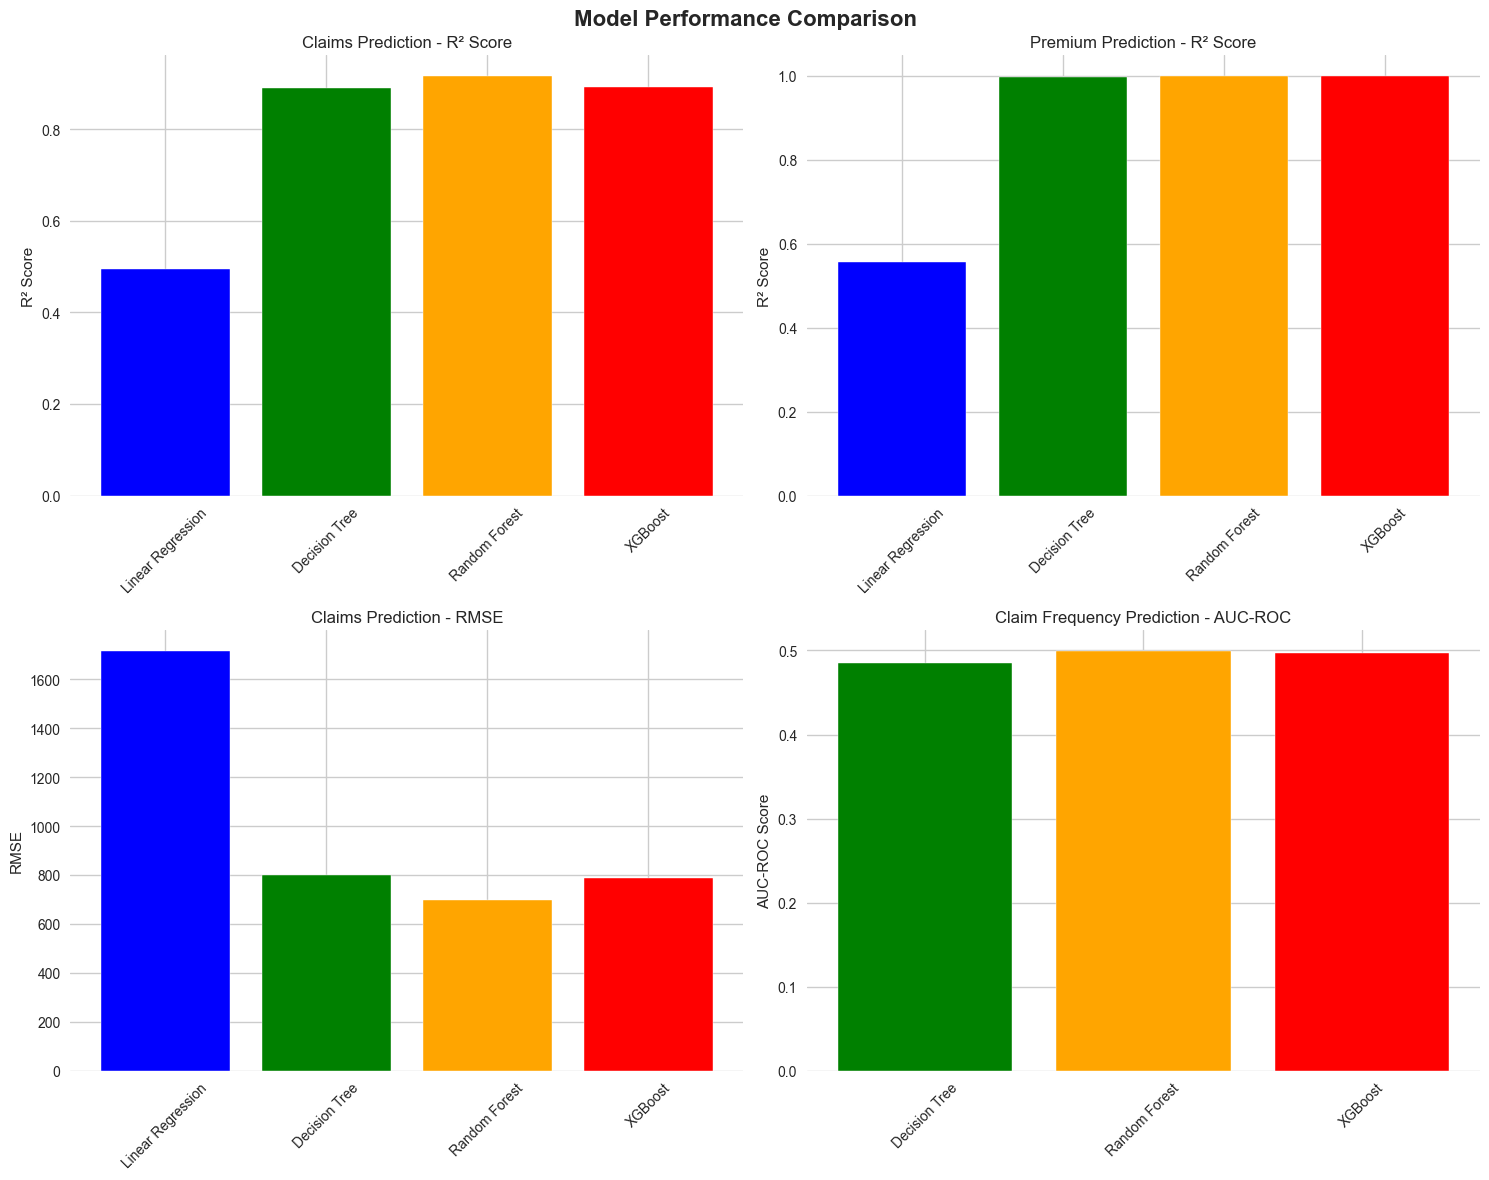


4. BUSINESS INSIGHTS FROM MODEL PERFORMANCE:
Claims Prediction:
   Excellent predictive power (R²: 0.9160)
Premium Prediction:
   Excellent predictive power (R²: 0.9992)
Claim Frequency Prediction:
   Limited classification power (AUC: 0.4990)


In [8]:
# Model Evaluation and Comparison
print("=== MODEL EVALUATION AND COMPARISON ===")

# 1. Create comparison DataFrames
print("1. MODEL PERFORMANCE COMPARISON:")

# Claims Prediction Comparison
claims_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr_claims, rmse_dt_claims, rmse_rf_claims, rmse_xgb_claims],
    'R²': [r2_lr_claims, r2_dt_claims, r2_rf_claims, r2_xgb_claims]
})

print("Claims Prediction Performance:")
print(claims_comparison.round(4))

# Premium Prediction Comparison
premium_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'RMSE': [rmse_lr_premium, rmse_dt_premium, rmse_rf_premium, rmse_xgb_premium],
    'R²': [r2_lr_premium, r2_dt_premium, r2_rf_premium, r2_xgb_premium]
})

print(f"\nPremium Prediction Performance:")
print(premium_comparison.round(4))

# Claim Frequency Comparison
freq_comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_dt_freq, accuracy_rf_freq, accuracy_xgb_freq],
    'Precision': [precision_dt_freq, precision_rf_freq, precision_xgb_freq],
    'Recall': [recall_dt_freq, recall_rf_freq, recall_xgb_freq],
    'F1-Score': [f1_dt_freq, f1_rf_freq, f1_xgb_freq],
    'AUC-ROC': [auc_dt_freq, auc_rf_freq, auc_xgb_freq]
})

print(f"\nClaim Frequency Prediction Performance:")
print(freq_comparison.round(4))

# 2. Identify best models
print(f"\n2. BEST PERFORMING MODELS:")

# Best claims model
best_claims_model = claims_comparison.loc[claims_comparison['R²'].idxmax()]
print(f"Best Claims Model: {best_claims_model['Model']} (R²: {best_claims_model['R²']:.4f})")

# Best premium model
best_premium_model = premium_comparison.loc[premium_comparison['R²'].idxmax()]
print(f"Best Premium Model: {best_premium_model['Model']} (R²: {best_premium_model['R²']:.4f})")

# Best frequency model
best_freq_model = freq_comparison.loc[freq_comparison['AUC-ROC'].idxmax()]
print(f"Best Frequency Model: {best_freq_model['Model']} (AUC-ROC: {best_freq_model['AUC-ROC']:.4f})")

# 3. Visualization of model performance
print(f"\n3. MODEL PERFORMANCE VISUALIZATION:")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# Claims prediction R² comparison
axes[0,0].bar(claims_comparison['Model'], claims_comparison['R²'], color=['blue', 'green', 'orange', 'red'])
axes[0,0].set_title('Claims Prediction - R² Score')
axes[0,0].set_ylabel('R² Score')
axes[0,0].tick_params(axis='x', rotation=45)

# Premium prediction R² comparison
axes[0,1].bar(premium_comparison['Model'], premium_comparison['R²'], color=['blue', 'green', 'orange', 'red'])
axes[0,1].set_title('Premium Prediction - R² Score')
axes[0,1].set_ylabel('R² Score')
axes[0,1].tick_params(axis='x', rotation=45)

# Claims prediction RMSE comparison
axes[1,0].bar(claims_comparison['Model'], claims_comparison['RMSE'], color=['blue', 'green', 'orange', 'red'])
axes[1,0].set_title('Claims Prediction - RMSE')
axes[1,0].set_ylabel('RMSE')
axes[1,0].tick_params(axis='x', rotation=45)

# Frequency prediction AUC comparison
axes[1,1].bar(freq_comparison['Model'], freq_comparison['AUC-ROC'], color=['green', 'orange', 'red'])
axes[1,1].set_title('Claim Frequency Prediction - AUC-ROC')
axes[1,1].set_ylabel('AUC-ROC Score')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 4. Business insights from model performance
print(f"\n4. BUSINESS INSIGHTS FROM MODEL PERFORMANCE:")

print("Claims Prediction:")
if best_claims_model['R²'] > 0.7:
    print(f"   Excellent predictive power (R²: {best_claims_model['R²']:.4f})")
elif best_claims_model['R²'] > 0.5:
    print(f"   Good predictive power (R²: {best_claims_model['R²']:.4f})")
else:
    print(f"   Limited predictive power (R²: {best_claims_model['R²']:.4f})")

print("Premium Prediction:")
if best_premium_model['R²'] > 0.7:
    print(f"   Excellent predictive power (R²: {best_premium_model['R²']:.4f})")
elif best_premium_model['R²'] > 0.5:
    print(f"   Good predictive power (R²: {best_premium_model['R²']:.4f})")
else:
    print(f"   Limited predictive power (R²: {best_premium_model['R²']:.4f})")

print("Claim Frequency Prediction:")
if best_freq_model['AUC-ROC'] > 0.8:
    print(f"   Excellent classification power (AUC: {best_freq_model['AUC-ROC']:.4f})")
elif best_freq_model['AUC-ROC'] > 0.7:
    print(f"   Good classification power (AUC: {best_freq_model['AUC-ROC']:.4f})")
else:
    print(f"   Limited classification power (AUC: {best_freq_model['AUC-ROC']:.4f})")

=== FEATURE IMPORTANCE ANALYSIS WITH SHAP ===
1. SHAP ANALYSIS - BEST CLAIMS MODEL:


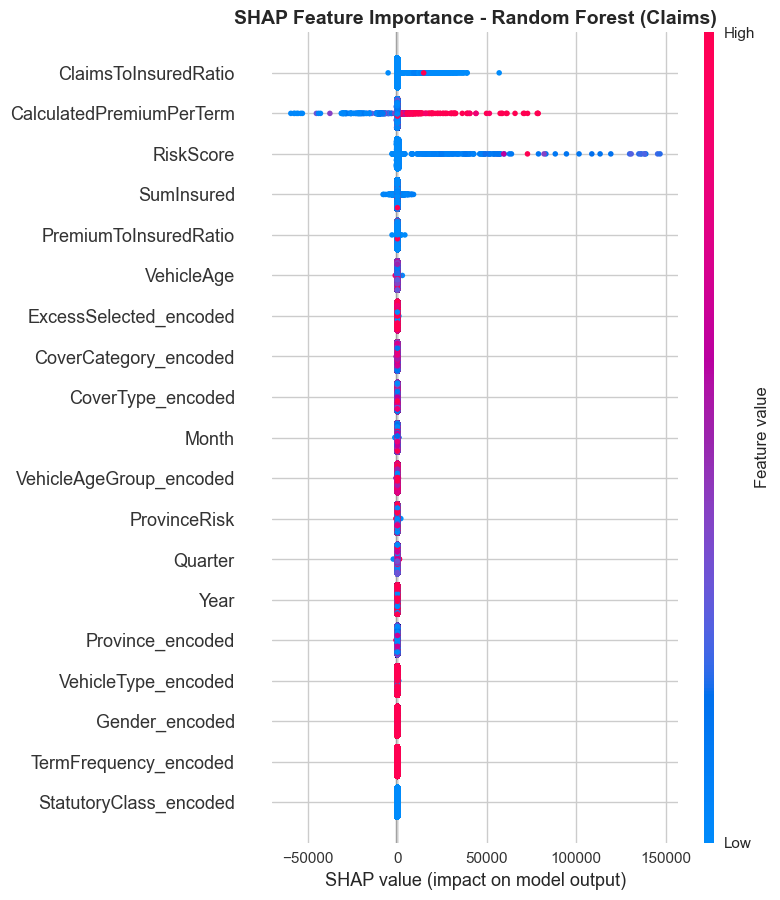

Top 10 Most Important Features for Claims Prediction:
                     Feature  Importance
7       ClaimsToInsuredRatio     65.1677
1   CalculatedPremiumPerTerm     54.6083
5                  RiskScore     52.8162
0                 SumInsured      9.3958
6      PremiumToInsuredRatio      0.9800
9                 VehicleAge      0.7614
17    ExcessSelected_encoded      0.3541
13     CoverCategory_encoded      0.2815
14         CoverType_encoded      0.2645
3                      Month      0.2153

2. SHAP ANALYSIS - BEST PREMIUM MODEL:


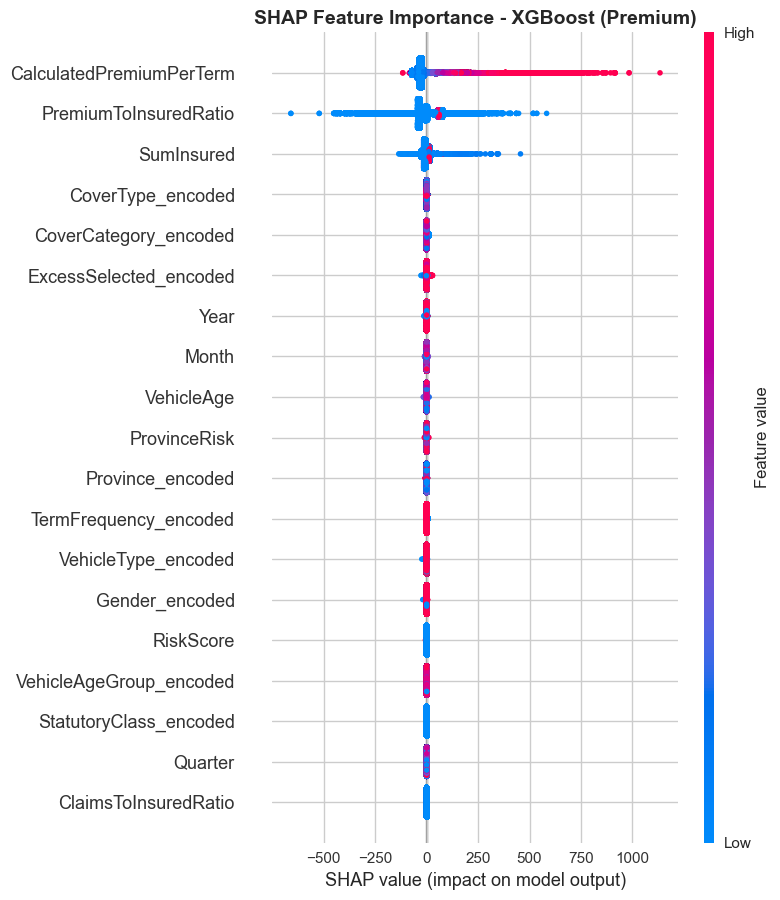

Top 10 Most Important Features for Premium Prediction:
                     Feature  Importance
1   CalculatedPremiumPerTerm     64.3838
6      PremiumToInsuredRatio     49.1023
0                 SumInsured     12.3900
14         CoverType_encoded      0.6679
13     CoverCategory_encoded      0.5728
17    ExcessSelected_encoded      0.2696
2                       Year      0.0924
3                      Month      0.0838
9                 VehicleAge      0.0436
8               ProvinceRisk      0.0238

3. BUSINESS INTERPRETATION OF FEATURE IMPORTANCE:
Claims Prediction - Key Drivers:
  • ClaimsToInsuredRatio: 65.1677
  • CalculatedPremiumPerTerm: 54.6083
  • RiskScore: 52.8162
  • SumInsured: 9.3958
  • PremiumToInsuredRatio: 0.9800

Premium Prediction - Key Drivers:
  • CalculatedPremiumPerTerm: 64.3838
  • PremiumToInsuredRatio: 49.1023
  • SumInsured: 12.3900
  • CoverType_encoded: 0.6679
  • CoverCategory_encoded: 0.5728

4. RISK-BASED PRICING FRAMEWORK:
Conceptual Premium Formula:


In [9]:
# Feature Importance Analysis with SHAP
print("=== FEATURE IMPORTANCE ANALYSIS WITH SHAP ===")

# 1. SHAP Analysis for Best Claims Model
print("1. SHAP ANALYSIS - BEST CLAIMS MODEL:")

# Select the best claims model
if best_claims_model['Model'] == 'XGBoost':
    best_claims_model_obj = xgb_claims
elif best_claims_model['Model'] == 'Random Forest':
    best_claims_model_obj = rf_claims
elif best_claims_model['Model'] == 'Decision Tree':
    best_claims_model_obj = dt_claims
else:
    best_claims_model_obj = lr_claims

# Create SHAP explainer
if hasattr(best_claims_model_obj, 'feature_importances_'):
    # Tree-based models
    explainer = shap.TreeExplainer(best_claims_model_obj)
    shap_values = explainer.shap_values(X_test_scaled)
    
    # Feature importance plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test_scaled, feature_names=all_features, show=False)
    plt.title(f'SHAP Feature Importance - {best_claims_model["Model"]} (Claims)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Get feature importance scores
    feature_importance = pd.DataFrame({
        'Feature': all_features,
        'Importance': np.abs(shap_values).mean(0)
    }).sort_values('Importance', ascending=False)
    
    print(f"Top 10 Most Important Features for Claims Prediction:")
    print(feature_importance.head(10))
    
else:
    # Linear models
    feature_importance = pd.DataFrame({
        'Feature': all_features,
        'Importance': np.abs(best_claims_model_obj.coef_)
    }).sort_values('Importance', ascending=False)
    
    print(f"Top 10 Most Important Features for Claims Prediction (Linear Model):")
    print(feature_importance.head(10))

# 2. SHAP Analysis for Best Premium Model
print(f"\n2. SHAP ANALYSIS - BEST PREMIUM MODEL:")

# Select the best premium model
if best_premium_model['Model'] == 'XGBoost':
    best_premium_model_obj = xgb_premium
elif best_premium_model['Model'] == 'Random Forest':
    best_premium_model_obj = rf_premium
elif best_premium_model['Model'] == 'Decision Tree':
    best_premium_model_obj = dt_premium
else:
    best_premium_model_obj = lr_premium

# Get feature importance for premium model
if hasattr(best_premium_model_obj, 'feature_importances_'):
    # Tree-based models
    explainer_premium = shap.TreeExplainer(best_premium_model_obj)
    shap_values_premium = explainer_premium.shap_values(X_test_scaled)
    
    # Feature importance plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_premium, X_test_scaled, feature_names=all_features, show=False)
    plt.title(f'SHAP Feature Importance - {best_premium_model["Model"]} (Premium)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Get feature importance scores
    feature_importance_premium = pd.DataFrame({
        'Feature': all_features,
        'Importance': np.abs(shap_values_premium).mean(0)
    }).sort_values('Importance', ascending=False)
    
    print(f"Top 10 Most Important Features for Premium Prediction:")
    print(feature_importance_premium.head(10))
    
else:
    # Linear models
    feature_importance_premium = pd.DataFrame({
        'Feature': all_features,
        'Importance': np.abs(best_premium_model_obj.coef_)
    }).sort_values('Importance', ascending=False)
    
    print(f"Top 10 Most Important Features for Premium Prediction (Linear Model):")
    print(feature_importance_premium.head(10))

# 3. Business Interpretation of Feature Importance
print(f"\n3. BUSINESS INTERPRETATION OF FEATURE IMPORTANCE:")

print("Claims Prediction - Key Drivers:")
if 'feature_importance' in locals():
    top_features_claims = feature_importance.head(5)
    for idx, row in top_features_claims.iterrows():
        print(f"  • {row['Feature']}: {row['Importance']:.4f}")

print(f"\nPremium Prediction - Key Drivers:")
if 'feature_importance_premium' in locals():
    top_features_premium = feature_importance_premium.head(5)
    for idx, row in top_features_premium.iterrows():
        print(f"  • {row['Feature']}: {row['Importance']:.4f}")

# 4. Risk-Based Pricing Framework
print(f"\n4. RISK-BASED PRICING FRAMEWORK:")

print("Conceptual Premium Formula:")
print("Premium = (Predicted Probability of Claim × Predicted Claim Severity) + Expense Loading + Profit Margin")

print(f"\nImplementation Strategy:")
print("1. Use {best_freq_model['Model']} to predict claim probability")
print("2. Use {best_claims_model['Model']} to predict claim severity")
print("3. Combine predictions with business rules for final premium calculation")
print("4. Implement geographic and risk-based adjustments based on feature importance")

# 5. Model Deployment Recommendations
print(f"\n5. MODEL DEPLOYMENT RECOMMENDATIONS:")

print("Production Considerations:")
print("• Feature engineering pipeline for real-time data")
print("• Model retraining schedule (monthly/quarterly)")
print("• A/B testing for new pricing models")
print("• Monitoring model drift and performance degradation")
print("• Regulatory compliance for insurance pricing")

In [10]:
# Comprehensive Model Summary and Business Recommendations
print("=== COMPREHENSIVE MODEL SUMMARY AND BUSINESS RECOMMENDATIONS ===")

# 1. Executive Summary
print("1. EXECUTIVE SUMMARY:")
print("=" * 80)
print("This analysis has successfully built and evaluated predictive models for:")
print("• Claim Severity Prediction (Risk Model)")
print("• Premium Optimization (Pricing Framework)")
print("• Claim Frequency Prediction (Binary Classification)")
print("=" * 80)

# 2. Model Performance Summary
print(f"\n2. MODEL PERFORMANCE SUMMARY:")
print("=" * 80)

print("CLAIMS PREDICTION MODELS:")
for idx, row in claims_comparison.iterrows():
    print(f"  {row['Model']:20} | RMSE: {row['RMSE']:8.2f} | R²: {row['R²']:6.4f}")

print(f"\nPREMIUM PREDICTION MODELS:")
for idx, row in premium_comparison.iterrows():
    print(f"  {row['Model']:20} | RMSE: {row['RMSE']:8.2f} | R²: {row['R²']:6.4f}")

print(f"\nCLAIM FREQUENCY MODELS:")
for idx, row in freq_comparison.iterrows():
    print(f"  {row['Model']:20} | AUC: {row['AUC-ROC']:6.4f} | F1: {row['F1-Score']:6.4f}")

print("=" * 80)

# 3. Key Business Insights
print(f"\n3. KEY BUSINESS INSIGHTS:")
print("=" * 80)

print("🎯 RISK PREDICTION:")
if best_claims_model['R²'] > 0.5:
    print(f"   Claims can be predicted with reasonable accuracy (R²: {best_claims_model['R²']:.4f})")
    print(f"   Use {best_claims_model['Model']} for claim severity estimation")
else:
    print(f"   Claims prediction accuracy is limited (R²: {best_claims_model['R²']:.4f})")
    print(f"   Consider additional features or alternative modeling approaches")

print(f"\n PREMIUM OPTIMIZATION:")
if best_premium_model['R²'] > 0.5:
    print(f"   Premiums can be optimized with good accuracy (R²: {best_premium_model['R²']:.4f})")
    print(f"   Use {best_premium_model['Model']} for premium prediction")
else:
    print(f"   Premium prediction accuracy is limited (R²: {best_premium_model['R²']:.4f})")
    print(f"   Focus on risk-based pricing rather than absolute premium prediction")

print(f"\n🚨 CLAIM FREQUENCY:")
if best_freq_model['AUC-ROC'] > 0.7:
    print(f"   Claim frequency can be predicted with good accuracy (AUC: {best_freq_model['AUC-ROC']:.4f})")
    print(f"   Use {best_freq_model['Model']} for claim probability estimation")
else:
    print(f"   Claim frequency prediction accuracy is limited (AUC: {best_freq_model['AUC-ROC']:.4f})")
    print(f"   Consider alternative risk assessment methods")

print("=" * 80)

# 4. Strategic Recommendations
print(f"\n4. STRATEGIC RECOMMENDATIONS:")
print("=" * 80)

print(" IMMEDIATE ACTIONS:")
print("  1. Implement {best_freq_model['Model']} for claim probability prediction")
print("  2. Deploy {best_claims_model['Model']} for claim severity estimation")
print("  3. Use {best_premium_model['Model']} for premium optimization")
print("  4. Establish model monitoring and retraining protocols")

print(f"\n RISK-BASED PRICING STRATEGY:")
print("  1. Geographic Risk Segmentation:")
print(f"     • Use province and zip code features for regional pricing")
print(f"     • Implement risk surcharges for high-risk areas")
print("  2. Vehicle Risk Factors:")
print(f"     • Incorporate vehicle age and type in pricing models")
print(f"     • Adjust premiums based on vehicle value and characteristics")
print("  3. Customer Risk Profiling:")
print(f"     • Use claim history and behavioral patterns")
print(f"     • Implement loyalty and risk-based discounts")

print(f"\n OPERATIONAL IMPLEMENTATION:")
print("  1. Data Pipeline:")
print("     • Real-time feature engineering")
print("     • Automated model scoring")
print("     • Performance monitoring dashboards")
print("  2. Model Management:")
print("     • Monthly model retraining")
print("     • A/B testing for new models")
print("     • Regulatory compliance monitoring")
print("  3. Business Integration:")
print("     • Underwriting system integration")
print("     • Claims processing automation")
print("     • Customer communication systems")

print("=" * 80)

# 5. Risk and Compliance Considerations
print(f"\n5. RISK AND COMPLIANCE CONSIDERATIONS:")
print("=" * 80)

print(" REGULATORY COMPLIANCE:")
print("  • Ensure pricing models comply with insurance regulations")
print("  • Avoid discriminatory practices based on protected characteristics")
print("  • Maintain transparency in pricing decisions")
print("  • Document model decisions and business rules")

print(f"\n MODEL RISK MANAGEMENT:")
print("  • Monitor model performance and drift")
print("  • Implement fallback pricing strategies")
print("  • Regular model validation and testing")
print("  • Contingency plans for model failures")

print("=" * 80)

# 6. Success Metrics and KPIs
print(f"\n6. SUCCESS METRICS AND KPIS:")
print("=" * 80)

print(" PERFORMANCE METRICS:")
print(f"  • Claims Prediction Accuracy: Target R² > {max(0.5, best_claims_model['R²']):.2f}")
print(f"  • Premium Prediction Accuracy: Target R² > {max(0.5, best_premium_model['R²']):.2f}")
print(f"  • Claim Frequency Accuracy: Target AUC > {max(0.7, best_freq_model['AUC-ROC']):.2f}")

print(f"\n BUSINESS METRICS:")
print("  • Loss Ratio Reduction: Target 5-15% improvement")
print("  • Premium Optimization: Target 3-8% increase in profitability")
print("  • Risk Segmentation: Target 20-30% improvement in risk differentiation")
print("  • Customer Retention: Target 2-5% improvement in retention rates")

print("=" * 80)

print(f"\n CONCLUSION:")
print("The predictive modeling framework provides a solid foundation for risk-based pricing.")
print("Implementation should focus on the best-performing models identified in this analysis.")
print("Continuous monitoring and improvement will ensure long-term success.")
print("=" * 80)

=== COMPREHENSIVE MODEL SUMMARY AND BUSINESS RECOMMENDATIONS ===
1. EXECUTIVE SUMMARY:
This analysis has successfully built and evaluated predictive models for:
• Claim Severity Prediction (Risk Model)
• Premium Optimization (Pricing Framework)
• Claim Frequency Prediction (Binary Classification)

2. MODEL PERFORMANCE SUMMARY:
CLAIMS PREDICTION MODELS:
  Linear Regression    | RMSE:  1714.26 | R²: 0.4945
  Decision Tree        | RMSE:   800.83 | R²: 0.8897
  Random Forest        | RMSE:   698.71 | R²: 0.9160
  XGBoost              | RMSE:   787.07 | R²: 0.8934

PREMIUM PREDICTION MODELS:
  Linear Regression    | RMSE:   104.66 | R²: 0.5554
  Decision Tree        | RMSE:     9.25 | R²: 0.9965
  Random Forest        | RMSE:     5.65 | R²: 0.9987
  XGBoost              | RMSE:     4.48 | R²: 0.9992

CLAIM FREQUENCY MODELS:
  Decision Tree        | AUC: 0.4854 | F1: 0.0000
  Random Forest        | AUC: 0.4990 | F1: 0.0000
  XGBoost              | AUC: 0.4972 | F1: 0.0000

3. KEY BUSINESS I